In [59]:
import h5py
from osgeo import gdal, osr
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from scipy.ndimage import binary_opening, binary_closing, generic_filter
import rasterio
from rasterio.transform import from_origin
from sklearn.decomposition import PCA

# Data Preparation

In [60]:

def generate_new_background(back, window_size=(3, 3), n_bands=None): # function to generate new background
    H, W = back.shape[:2] # pull out the height and width from the shape
    if n_bands is None: # calculate the number of bands 
        n_bands = back.shape[2]

    wh, ww = window_size # assign window variables 
    pad_h, pad_w = wh // 2, ww // 2 # pad variables  by half their value rounded down
    rng = np.random.default_rng() # random number generator 

    new_bands = [] # make empty list 
    for b in tqdm.tqdm(range(n_bands)): # cycle through the bands, tqdm gives a progress bar
        band = back[:, :, b] # select individual band

        # pad so the sliding-window output matches the original H, W
        padded = np.pad(band, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect') 
        window = sliding_window_view(padded, window_shape=window_size)  # (H, W, wh, ww) make the sliding window
        out_h, out_w = window.shape[:2] # create the out height and width

        flat = window.reshape(out_h, out_w, wh * ww) # make the window flat in the last dimesion (i.e. band)
        idx = rng.integers(0, wh * ww, size=(out_h, out_w)) # make random values in the range of the flattened band
        moving_sample = np.take_along_axis(flat, idx[..., None], axis=-1)[..., 0]  # randomly select a value from the background values in the flattened array

        new_bands.append(moving_sample) # build array 

    return np.stack(new_bands, axis=-1) # return the new array 


In [61]:

with h5py.File(r'/pool/gis/chris/Tanager Competition/20250724_190927_83_4001_ortho_radiance_hdf5.h5', 'r') as f:
    # attrs on the radiance dataset itself
    ds = f['HDFEOS/GRIDS/HYP/Data Fields/toa_radiance']
    
    print("toa_radiance attrs:")
    for k, v in ds.attrs.items(): # get wavelength centers and fwhm values 
        print(" ", k, "->", v)
        print(k)
        if k == 'wavelengths':
            wavelengths = np.array(v)
        elif k == 'fwhm':
            fwhm = np.array(v)
    radiance = f['HDFEOS/GRIDS/HYP/Data Fields/toa_radiance'][:]
    cloud_mask = f['HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask'][:]
    cirrus_mask = f['HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask'][:]
    nodata = f['HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels'][:]

toa_radiance attrs:
  Unit -> W/(m^2 sr um)
Unit
  _FillValue -> -9999.0
_FillValue
  applied_radiometric_coefficients -> [0.24117877 0.19664247 0.12794702 0.10599381 0.0785861  0.06810818
 0.05935678 0.04755091 0.04190101 0.03722739 0.03394626 0.0303052
 0.02826379 0.02598685 0.02387025 0.02336355 0.02251674 0.02208806
 0.02204469 0.02220925 0.02168082 0.02049176 0.01993347 0.01987995
 0.01913034 0.01838925 0.01796245 0.01744622 0.01674083 0.01709536
 0.01676122 0.01611635 0.01537274 0.01469532 0.0143942  0.01404121
 0.01360779 0.01338364 0.01328742 0.01275896 0.01256888 0.01229605
 0.01184709 0.01151312 0.01140921 0.01112384 0.01085087 0.01073875
 0.01054627 0.01030221 0.0100322  0.01017956 0.01043109 0.01048737
 0.01056168 0.01062509 0.01038046 0.01180799 0.01294908 0.01158617
 0.01024127 0.01051945 0.01077913 0.01044896 0.00998824 0.00947738
 0.00940376 0.00939155 0.00935765 0.00926195 0.00920742 0.00921969
 0.00927409 0.00924037 0.00916314 0.0090442  0.00935355 0.00856564
 0.00894

In [62]:
good = ( # mask for no-data and clouds
    (nodata == 0) &
    (cloud_mask == 0) 
    # (cirrus_mask == 0)
)
radiance = np.moveaxis(radiance, 0, -1) # move axis so the shape is 702, 846, 426 

radiance.shape # print out shape to confirm

(702, 846, 426)

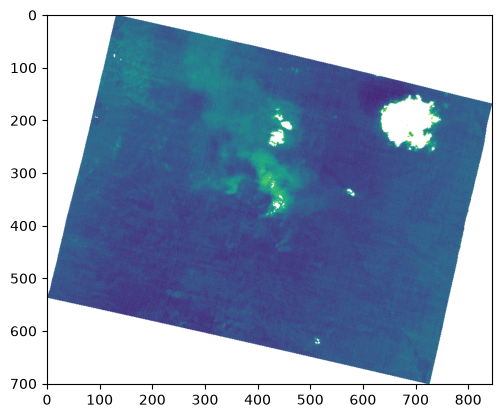

In [63]:
radiance[~good, :] = np.nan # apply nan's to the mask values 
plt.imshow(radiance[:,:,1])# show masked data to confirm

# Data Modelling
## Plume Mask
plume mask modeling is based on the following article:  
Ning, Z., Li, Z., Qian, R., Fang, Y. 2025. Towards gas plume identification in industrial and livestock farm environments using infrared hyperspectral imaging: A background modeling and suppression method. Agriculture, 15(17), 1835. https://doi.org/10.3390/agriculture15171835

In [64]:
background  = radiance[:,:,0:3] # select background grids 
back = generate_new_background(background) # generate 3 background bands 
back2 = generate_new_background(background) # generate 3 background bands
back = np.dstack([background,back, back2]) # combine all the background bands so that there is 9 total background bands 

100%|██████████| 3/3 [00:00<00:00, 104.18it/s]


In [65]:
nb = radiance[:,:,:]
print(nb.shape)
print(back.shape)

(702, 846, 426)
(702, 846, 9)


In [66]:

diff = nb * 9 - back.sum(axis=-1, keepdims=True) # The difference here is each pixel nb[i,j,z] * 9 (To scale accordingly) - sum of the pixel values in the 9 bands of the background

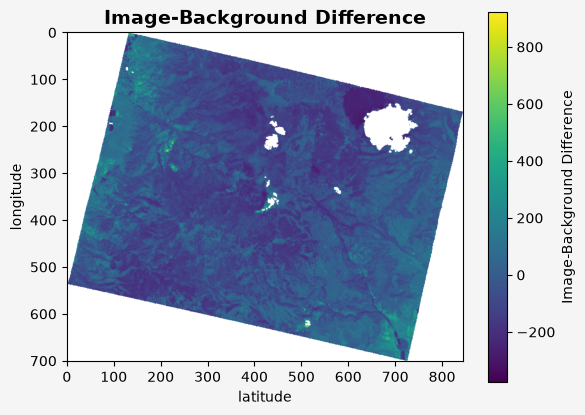

In [67]:
plt.imshow(diff[:,:, 50]) # show the difference raster at band 50 - this is just a test
plt.title("Image-Background Difference",
            fontsize=14,
          fontweight='bold')
plt.gcf().set_facecolor('whitesmoke')
plt.xlabel('latitude')
plt.ylabel('longitude')
plt.colorbar(label = 'Image-Background Difference')

Text(0, 0.5, 'Image-Background Difference')

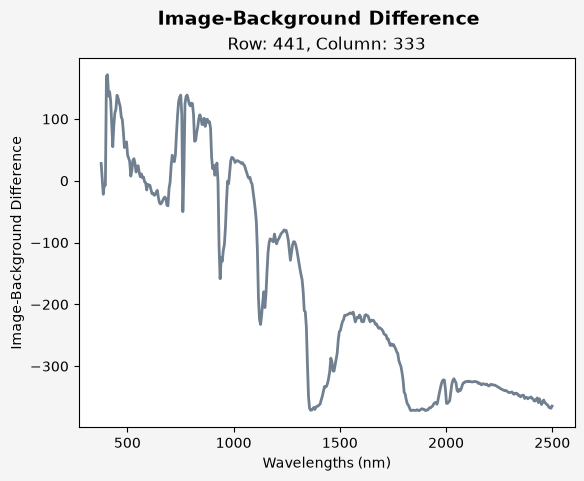

In [68]:
row = 441 # change row/column based on pixel of interest
column = 333
plt.style.use('petroff6')
plt.gcf().set_facecolor('whitesmoke')
plt.plot(wavelengths, diff[row,column,:], color = 'slategrey', lw='2') # plot the wavelengths for a single cell
plt.suptitle(f"Image-Background Difference",
          fontsize=14,
          fontweight='bold')
plt.title(f'Row: {str(row)}, Column: {str(column)}')
plt.xlabel("Wavelengths (nm)")
plt.ylabel('Image-Background Difference')

In [69]:
band_min = np.nanmin(diff, axis=(0,1), keepdims = True) # get the minimum of diff 
band_max = np.nanmax(diff, axis=(0,1), keepdims=True) # get the maximum of diff
scaled = (band_max - diff) / (band_max - band_min) # normalize values so higher values mean higher likelihood of Co2

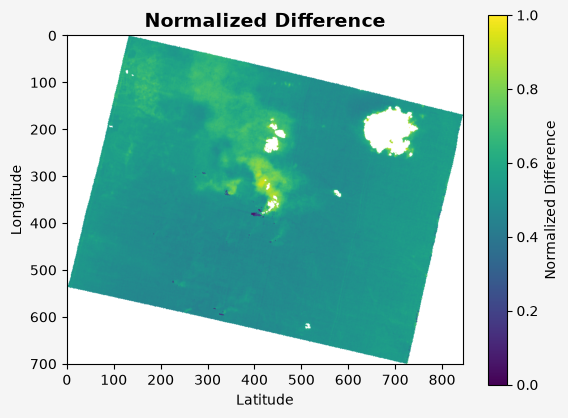

In [70]:
plt.imshow(scaled[:,:,370]) # show the scaled differences
plt.colorbar(label='Normalized Difference')
plt.title("Normalized Difference",
                    fontsize=14,
          fontweight='bold')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.gcf().set_facecolor('whitesmoke')

In [71]:
co2_band = np.where( # wavelengths where we would expect to see Co2 absorbtion
    (wavelengths > 2000) &
    (wavelengths < 2300)
)[0]

In [72]:
co2_scaled = scaled[:,:,co2_band] # pull out only the scaled values from the co2 bands
mn = np.nanmean(co2_scaled, axis = -1) # get the mean values of the scaled co2 bands
plume = np.zeros_like(mn) # make an empty array of the same shape as mn
plume.astype('bool') # set the type to boolean
plume[np.where(mn > 0.6)] =1 # if the value is greater than 0.6, specify the value as a plume

/tmp/ipykernel_3360635/369290150.py:2: RuntimeWarning: Mean of empty slice
  mn = np.nanmean(co2_scaled, axis = -1) # get the mean values of the scaled co2 bands


Text(0, 0.5, 'Longitude')

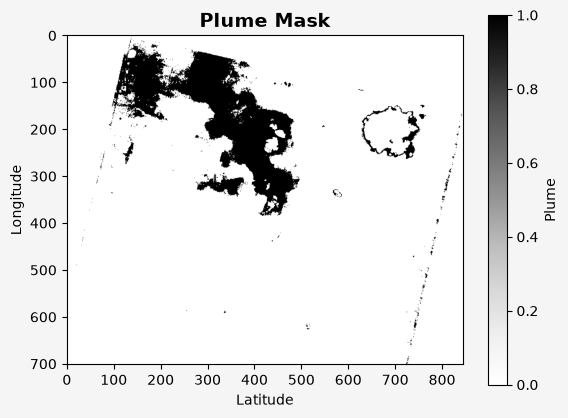

In [80]:
plt.imshow(plume, cmap="Greys") # show the plume mask 
plt.colorbar(label = 'Plume')
plt.title('Plume Mask',
          fontsize=14,
          fontweight='bold')
plt.gcf().set_facecolor('whitesmoke')
plt.xlabel('Latitude')
plt.ylabel('Longitude')

In [ ]:
plume_mask = plume
plume_mask[plume_mask == 0] = np.nan
plt.imshow(plume_mask)

## Export Plume Mask Results

In [ ]:
src_ds = gdal.Open(r'/pool/gis/chris/Tanager Competition/20250724_190927_83_4001_ortho_visual.tif') # open the .tif of hte visual file using gdal
geotransform = src_ds.GetGeoTransform() # get the transformation/projection of the data 
projection = src_ds.GetProjection()
geotransform

In [ ]:
rows,cols = plume.shape[0], plume.shape[1] # make the number of rows and columns equal to plume
bands = 1 # 1 band
gdal_dtype = gdal.GDT_Float32 # set the gdal data type  
driver = gdal.GetDriverByName('GTiff') # set the driver
out_ds = driver.Create(
    r'/pool/gis/chris/Tanager Competition/Tanager-Wildfire-Analysis/Data/mn_val.tif', # file path for saving the dataset 
    cols,rows, bands, gdal_dtype # other parameters
)
out_ds.SetGeoTransform(geotransform) # set the transformation

srs = osr.SpatialReference() # change projection
srs.ImportFromEPSG(32612)
out_ds.SetProjection(srs.ExportToWkt())

out_ds.GetRasterBand(1).WriteArray(mn) # write mn array as the raster 
out_ds.FlushCache()
out_ds.Close()